In [1]:
# Imports
import os
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

warnings.filterwarnings("ignore")
%matplotlib inline

2026-03-19 17:31:57.677017: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-19 17:31:57.677129: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-19 17:31:57.789641: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
# Paths and settings
attr_path = "/kaggle/input/celeba-dataset/list_attr_celeba.csv"
partition_path = "/kaggle/input/celeba-dataset/list_eval_partition.csv"
img_dir = "/kaggle/input/celeba-dataset/img_align_celeba/img_align_celeba/"

# Image size and constants
IMG_SIZE = (218, 178)
BATCH_SIZE = 32
EPOCHS = 5

In [3]:
# Read attribute and partition files
data = pd.read_csv(attr_path)
partition = pd.read_csv(partition_path)

data = data[["image_id", "Male", "Young"]].copy()

# Normalization
data["Male"] = data["Male"].replace({-1: 0, 1: 1})
data["Young"] = data["Young"].replace({-1: 0, 1: 1})

df = pd.merge(data, partition, on="image_id", how="inner")

df.head()

,image_id,Male,Young,partition
0,000001.jpg,0,1,0
1,000002.jpg,0,1,0
2,000003.jpg,1,1,0
3,000004.jpg,0,1,0
4,000005.jpg,0,1,0


In [4]:
# Partition mapping
train_df = df[df["partition"] == 0].copy()
val_df   = df[df["partition"] == 1].copy()
test_df  = df[df["partition"] == 2].copy()

print("Original sizes")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Original sizes
Train: 162770
Val:   19867
Test:  19962


In [5]:
#sample sizes
train_df = train_df.sample(frac=0.1, random_state=42).reset_index(drop=True)
val_df   = val_df.sample(n=1000, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(n=1000, random_state=42).reset_index(drop=True)

print("Sampled sizes")
print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

Sampled sizes
Train: 16277
Val:   1000
Test:  1000


In [6]:
# Data generator
class DataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, target_cols, batch_size=BATCH_SIZE, dim=IMG_SIZE, n_channels=3, shuffle=False):
        self.df = df.reset_index(drop=True).copy()
        self.target_cols = target_cols
        self.batch_size = batch_size
        self.dim = dim
        self.n_channels = n_channels
        self.n_classes = len(target_cols)
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        df_temp = self.df.iloc[indexes].reset_index(drop=True)
        X, y = self.__data_generation(df_temp)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, df_temp):
        current_batch_size = len(df_temp)
        X = np.empty((current_batch_size, *self.dim, self.n_channels), dtype=np.float32)
        y = np.empty((current_batch_size, self.n_classes), dtype=np.float32)

        for i, row in df_temp.iterrows():
            img_path = os.path.join(img_dir, row["image_id"])
            img = image.load_img(img_path, target_size=self.dim)
            img = image.img_to_array(img)
            img /= 255.0
            X[i] = img
            y[i] = row[self.target_cols].values.astype(np.float32)

        return X, y

In [7]:
# Build model using pretrained VGG16 as frozen feature extractor
def build_model(output_dim):
    base_model = VGG16(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    model = tf.keras.Sequential([
        base_model,
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(256, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(output_dim, activation="sigmoid")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [8]:
# Confusion matrix helper function
def plot_conf_matrix(cm, class_names, title="Confusion Matrix"):
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_names))
    plt.xticks(tick_marks, class_names, rotation=45)
    plt.yticks(tick_marks, class_names)

    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(
            j, i, format(cm[i, j], "d"),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

In [9]:
# Helper for 4 class labels
def combine_gender_age(gender, young):
    if gender == 0 and young == 0:
        return "Female_Old"
    elif gender == 0 and young == 1:
        return "Female_Young"
    elif gender == 1 and young == 0:
        return "Male_Old"
    else:
        return "Male_Young"

labels4 = ["Female_Old", "Female_Young", "Male_Old", "Male_Young"]

In [10]:
# R1 generators
r1_targets = ["Male"]

train_gen_r1 = DataGenerator(train_df, target_cols=r1_targets, batch_size=BATCH_SIZE, shuffle=True)
val_gen_r1   = DataGenerator(val_df, target_cols=r1_targets, batch_size=BATCH_SIZE, shuffle=False)
test_gen_r1  = DataGenerator(test_df, target_cols=r1_targets, batch_size=BATCH_SIZE, shuffle=False)

In [11]:
# Build and train M1
tf.keras.backend.clear_session()

model_m1 = build_model(output_dim=1)

callbacks_m1 = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    )
]

history_m1 = model_m1.fit(
    train_gen_r1,
    validation_data=val_gen_r1,
    epochs=EPOCHS,
    callbacks=callbacks_m1,
    verbose=1
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
  1/509 ━━━━━━━━━━━━━━━━━━━━ 3:57:57 28s/step - accuracy: 0.5938 - loss: 0.7942

I0000 00:00:1773941559.145674      74 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1773941559.164293      74 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


318/509 ━━━━━━━━━━━━━━━━━━━━ 46s 246ms/step - accuracy: 0.8269 - loss: 0.5190

W0000 00:00:1773941636.905246      73 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step - accuracy: 0.8510 - loss: 0.4301

W0000 00:00:1773941671.641429      74 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 155s 250ms/step - accuracy: 0.8511 - loss: 0.4298 - val_accuracy: 0.9320 - val_loss: 0.1710
Epoch 2/5


W0000 00:00:1773941685.899003      75 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 65s 127ms/step - accuracy: 0.9386 - loss: 0.1634 - val_accuracy: 0.9410 - val_loss: 0.1514
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.9416 - loss: 0.1488 - val_accuracy: 0.9410 - val_loss: 0.1455
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.9549 - loss: 0.1159 - val_accuracy: 0.9360 - val_loss: 0.1552
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.9585 - loss: 0.1081 - val_accuracy: 0.9340 - val_loss: 0.1740
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


R1 / M1 Gender Accuracy: 0.927

R1 / M1 Confusion Matrix:
[[569  52]
 [ 21 358]]

R1 / M1 Classification Report:
              precision    recall  f1-score   support

      Female       0.96      0.92      0.94       621
        Male       0.87      0.94      0.91       379

    accuracy                           0.93      1000
   macro avg       0.92      0.93      0.92      1000
weighted avg       0.93      0.93      0.93      1000



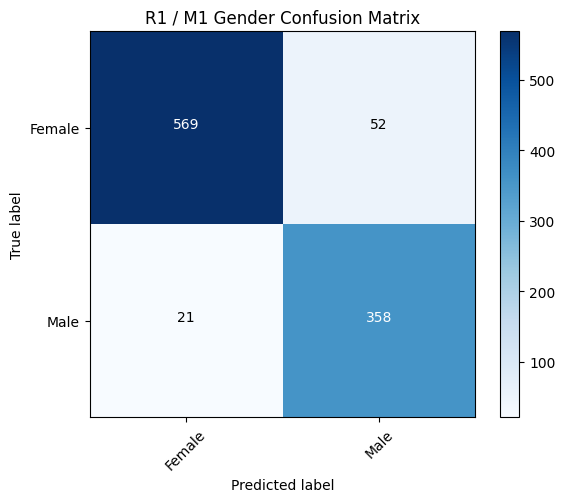

In [12]:
# Evaluation on gender only 
pred_probs_m1_r1 = model_m1.predict(test_gen_r1, verbose=0)
y_pred_m1_r1 = (pred_probs_m1_r1.ravel() > 0.5).astype(int)
y_true_m1_r1 = test_df["Male"].values[:len(y_pred_m1_r1)].astype(int)

cm_r1 = confusion_matrix(y_true_m1_r1, y_pred_m1_r1)
acc_r1 = accuracy_score(y_true_m1_r1, y_pred_m1_r1)

print("R1 / M1 Gender Accuracy:", acc_r1)
print("\nR1 / M1 Confusion Matrix:")
print(cm_r1)
print("\nR1 / M1 Classification Report:")
print(classification_report(y_true_m1_r1, y_pred_m1_r1, target_names=["Female", "Male"]))

plot_conf_matrix(cm_r1, ["Female", "Male"], title="R1 / M1 Gender Confusion Matrix")

Majority age class from training data: 1
R2 Step 1 / M1 4-Class Accuracy: 0.699

R2 Step 1 / M1 4-Class Confusion Matrix:
[[  0  92   0  17]
 [  0 477   0  35]
 [  0   3   0 136]
 [  0  18   0 222]]

R2 Step 1 / M1 4-Class Classification Report:
              precision    recall  f1-score   support

  Female_Old       0.00      0.00      0.00       109
Female_Young       0.81      0.93      0.87       512
    Male_Old       0.00      0.00      0.00       139
  Male_Young       0.54      0.93      0.68       240

    accuracy                           0.70      1000
   macro avg       0.34      0.46      0.39      1000
weighted avg       0.54      0.70      0.61      1000



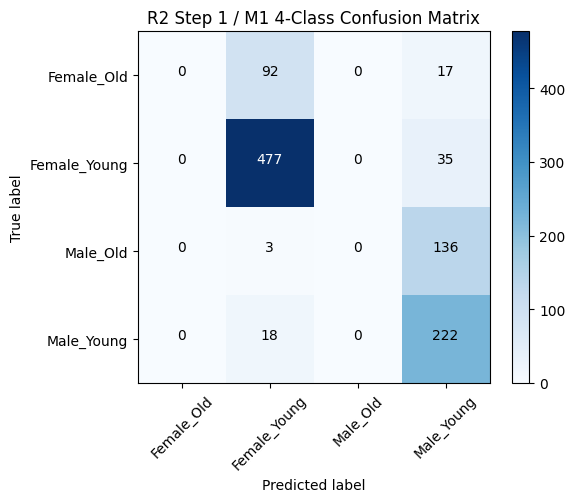

In [13]:
# R2 

majority_age = int(train_df["Young"].mode()[0])
print("Majority age class from training data:", majority_age)

true_group4_m1 = [
    combine_gender_age(g, a)
    for g, a in zip(test_df["Male"].values.astype(int), test_df["Young"].values.astype(int))
]

pred_group4_m1 = [
    combine_gender_age(g_pred, majority_age)
    for g_pred in y_pred_m1_r1
]

cm_m1_r2 = confusion_matrix(true_group4_m1, pred_group4_m1, labels=labels4)
acc_m1_r2 = accuracy_score(true_group4_m1, pred_group4_m1)

print("R2 Step 1 / M1 4-Class Accuracy:", acc_m1_r2)
print("\nR2 Step 1 / M1 4-Class Confusion Matrix:")
print(cm_m1_r2)
print("\nR2 Step 1 / M1 4-Class Classification Report:")
print(classification_report(true_group4_m1, pred_group4_m1, labels=labels4))

plot_conf_matrix(cm_m1_r2, labels4, title="R2 Step 1 / M1 4-Class Confusion Matrix")

In [14]:
# R2 generators
r2_targets = ["Male", "Young"]

train_gen_m2 = DataGenerator(train_df, target_cols=r2_targets, batch_size=BATCH_SIZE, shuffle=True)
val_gen_m2   = DataGenerator(val_df, target_cols=r2_targets, batch_size=BATCH_SIZE, shuffle=False)
test_gen_m2  = DataGenerator(test_df, target_cols=r2_targets, batch_size=BATCH_SIZE, shuffle=False)

In [15]:
# Build and train M2
tf.keras.backend.clear_session()

model_m2 = build_model(output_dim=2)

callbacks_m2 = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    )
]

history_m2 = model_m2.fit(
    train_gen_m2,
    validation_data=val_gen_m2,
    epochs=EPOCHS,
    callbacks=callbacks_m2,
    verbose=1
)

Epoch 1/5
  1/509 ━━━━━━━━━━━━━━━━━━━━ 32:51 4s/step - accuracy: 0.5000 - loss: 0.6523

W0000 00:00:1773941962.791636      73 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


374/509 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.7668 - loss: 0.4936

W0000 00:00:1773942010.208263      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7787 - loss: 0.4571

W0000 00:00:1773942027.661276      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 73s 136ms/step - accuracy: 0.7788 - loss: 0.4569 - val_accuracy: 0.8440 - val_loss: 0.2932
Epoch 2/5


W0000 00:00:1773942031.797253      74 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8513 - loss: 0.2692 - val_accuracy: 0.8160 - val_loss: 0.3042
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8596 - loss: 0.2360 - val_accuracy: 0.8230 - val_loss: 0.2817
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8623 - loss: 0.2179 - val_accuracy: 0.8510 - val_loss: 0.2773
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8696 - loss: 0.2072 - val_accuracy: 0.8540 - val_loss: 0.2730
Restoring model weights from the end of the best epoch: 5.


W0000 00:00:1773942298.528413      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1773942302.556969      74 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


R2 Step 2 / M2 4-Class Accuracy: 0.779

R2 Step 2 / M2 4-Class Confusion Matrix:
[[ 15  79  15   0]
 [  6 488   3  15]
 [  0   3  99  37]
 [  1  31  31 177]]

R2 Step 2 / M2 4-Class Classification Report:
              precision    recall  f1-score   support

  Female_Old       0.68      0.14      0.23       109
Female_Young       0.81      0.95      0.88       512
    Male_Old       0.67      0.71      0.69       139
  Male_Young       0.77      0.74      0.75       240

    accuracy                           0.78      1000
   macro avg       0.73      0.64      0.64      1000
weighted avg       0.77      0.78      0.75      1000



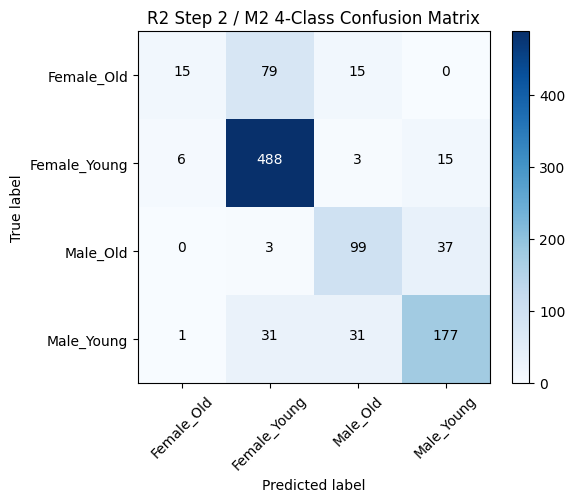

In [16]:
# Evaluate M2 on true 4 class task
pred_probs_m2 = model_m2.predict(test_gen_m2, verbose=0)

pred_male_m2  = (pred_probs_m2[:, 0] > 0.5).astype(int)
pred_young_m2 = (pred_probs_m2[:, 1] > 0.5).astype(int)

true_group4_m2 = [
    combine_gender_age(g_true, a_true)
    for g_true, a_true in zip(test_df["Male"].values.astype(int), test_df["Young"].values.astype(int))
]

pred_group4_m2 = [
    combine_gender_age(g_pred, a_pred)
    for g_pred, a_pred in zip(pred_male_m2, pred_young_m2)
]

cm_m2_r2 = confusion_matrix(true_group4_m2, pred_group4_m2, labels=labels4)
acc_m2_r2 = accuracy_score(true_group4_m2, pred_group4_m2)

print("R2 Step 2 / M2 4-Class Accuracy:", acc_m2_r2)
print("\nR2 Step 2 / M2 4-Class Confusion Matrix:")
print(cm_m2_r2)
print("\nR2 Step 2 / M2 4-Class Classification Report:")
print(classification_report(true_group4_m2, pred_group4_m2, labels=labels4))

plot_conf_matrix(cm_m2_r2, labels4, title="R2 Step 2 / M2 4-Class Confusion Matrix")

In [17]:
print("FINAL COMPARISON")
print(f"R1 / M1 Gender Accuracy:      {acc_r1:.4f}")
print(f"R2 Step 1 / M1 4-Class Acc:   {acc_m1_r2:.4f}")
print(f"R2 Step 2 / M2 4-Class Acc:   {acc_m2_r2:.4f}")

FINAL COMPARISON
R1 / M1 Gender Accuracy:      0.9270
R2 Step 1 / M1 4-Class Acc:   0.6990
R2 Step 2 / M2 4-Class Acc:   0.7790


In [18]:
drop_m1 = acc_r1 - acc_m1_r2
gain_m2 = acc_m2_r2 - acc_m1_r2

print("Accuracy drop from R1 to R2 Step 1 (M1):", round(drop_m1, 4))
print("Accuracy gain from M1 to M2 on 4-class task:", round(gain_m2, 4))

if acc_m1_r2 < acc_r1:
    print("\nConclusion: M1 does not generalize well when age is introduced into the target space.")
else:
    print("\nConclusion: M1 appears to generalize reasonably well with age.")

if acc_m2_r2 > acc_m1_r2:
    print("M2 improves performance on the 4-class gender+age task.")
    print("This supports the conclusion that gender classification does not generalize with age on pixel data alone.")
else:
    print("M2 did not improve enough to strongly support the conclusion.")

Accuracy drop from R1 to R2 Step 1 (M1): 0.228
Accuracy gain from M1 to M2 on 4-class task: 0.08

Conclusion: M1 does not generalize well when age is introduced into the target space.
M2 improves performance on the 4-class gender+age task.
This supports the conclusion that gender classification does not generalize with age on pixel data alone.


In [19]:
# R3 paths
landmarks_path = "/kaggle/input/celeba-dataset/list_landmarks_align_celeba.csv"

In [20]:
# Reload attributes with Smiling included
attr_r3 = pd.read_csv(attr_path)
partition_r3 = pd.read_csv(partition_path)
landmarks = pd.read_csv(landmarks_path)

attr_r3 = attr_r3[["image_id", "Smiling"]].copy()
attr_r3["Smiling"] = attr_r3["Smiling"].replace({-1: 0, 1: 1})

landmarks = landmarks[["image_id", "leftmouth_x", "rightmouth_x"]].copy()

df_r3 = pd.merge(attr_r3, partition_r3, on="image_id", how="inner")
df_r3 = pd.merge(df_r3, landmarks, on="image_id", how="inner")

# Compute mouth width
df_r3["mouth_width"] = df_r3["rightmouth_x"] - df_r3["leftmouth_x"]

df_r3.head()

,image_id,Smiling,partition,leftmouth_x,rightmouth_x,mouth_width
0,000001.jpg,1,0,73,108,35
1,000002.jpg,1,0,70,108,38
2,000003.jpg,0,0,74,98,24
3,000004.jpg,0,0,71,101,30
4,000005.jpg,0,0,71,104,33


In [21]:
# Partitions
r3_train_df = df_r3[df_r3["partition"] == 0].copy()
r3_val_df   = df_r3[df_r3["partition"] == 1].copy()
r3_test_df  = df_r3[df_r3["partition"] == 2].copy()

print("Original R3 sizes")
print("Train:", len(r3_train_df))
print("Val:  ", len(r3_val_df))
print("Test: ", len(r3_test_df))

Original R3 sizes
Train: 162770
Val:   19867
Test:  19962


In [22]:
# Sampling
r3_train_df = r3_train_df.sample(frac=0.1, random_state=42).reset_index(drop=True)
r3_val_df   = r3_val_df.sample(n=1000, random_state=42).reset_index(drop=True)
r3_test_df  = r3_test_df.sample(n=1000, random_state=42).reset_index(drop=True)

print("Sampled R3 sizes")
print("Train:", len(r3_train_df))
print("Val:  ", len(r3_val_df))
print("Test: ", len(r3_test_df))

Sampled R3 sizes
Train: 16277
Val:   1000
Test:  1000


In [23]:
# Create mouth width quartiles
quartile_edges = np.quantile(r3_train_df["mouth_width"], [0.25, 0.50, 0.75])
print("Quartile edges:", quartile_edges)

def assign_quartile(x, edges):
    if x <= edges[0]:
        return 0
    elif x <= edges[1]:
        return 1
    elif x <= edges[2]:
        return 2
    else:
        return 3

r3_train_df["mouth_quartile"] = r3_train_df["mouth_width"].apply(lambda x: assign_quartile(x, quartile_edges))
r3_val_df["mouth_quartile"]   = r3_val_df["mouth_width"].apply(lambda x: assign_quartile(x, quartile_edges))
r3_test_df["mouth_quartile"]  = r3_test_df["mouth_width"].apply(lambda x: assign_quartile(x, quartile_edges))

r3_train_df[["image_id", "Smiling", "mouth_width", "mouth_quartile"]].head()

Quartile edges: [30. 34. 39.]


,image_id,Smiling,mouth_width,mouth_quartile
0,056354.jpg,0,5,0
1,130368.jpg,1,38,2
2,098887.jpg,0,28,0
3,039403.jpg,0,26,0
4,080965.jpg,0,37,2


In [24]:
# Baseline R3 generator with smiling only
r3_targets = ["Smiling"]

train_gen_r3_base = DataGenerator(r3_train_df, target_cols=r3_targets, batch_size=BATCH_SIZE, shuffle=True)
val_gen_r3_base   = DataGenerator(r3_val_df, target_cols=r3_targets, batch_size=BATCH_SIZE, shuffle=False)
test_gen_r3_base  = DataGenerator(r3_test_df, target_cols=r3_targets, batch_size=BATCH_SIZE, shuffle=False)

In [25]:
# Train baseline smiling model
tf.keras.backend.clear_session()

model_r3_base = build_model(output_dim=1)

callbacks_r3_base = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    )
]

history_r3_base = model_r3_base.fit(
    train_gen_r3_base,
    validation_data=val_gen_r3_base,
    epochs=EPOCHS,
    callbacks=callbacks_r3_base,
    verbose=1
)

Epoch 1/5
  1/509 ━━━━━━━━━━━━━━━━━━━━ 30:13 4s/step - accuracy: 0.3750 - loss: 0.9457

W0000 00:00:1773942312.479016      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


373/509 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.7393 - loss: 0.6793

W0000 00:00:1773942359.852406      75 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7554 - loss: 0.6203

W0000 00:00:1773942377.105633      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 72s 135ms/step - accuracy: 0.7555 - loss: 0.6200 - val_accuracy: 0.8510 - val_loss: 0.3458
Epoch 2/5


W0000 00:00:1773942380.993039      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 128ms/step - accuracy: 0.8573 - loss: 0.3362 - val_accuracy: 0.8770 - val_loss: 0.2902
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8771 - loss: 0.2961 - val_accuracy: 0.8700 - val_loss: 0.2999
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8911 - loss: 0.2584 - val_accuracy: 0.8720 - val_loss: 0.2953
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


R3 Baseline Smiling Accuracy: 0.86

R3 Baseline Smiling Confusion Matrix:
[[429  60]
 [ 80 431]]

R3 Baseline Classification Report:
              precision    recall  f1-score   support

 Not Smiling       0.84      0.88      0.86       489
     Smiling       0.88      0.84      0.86       511

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



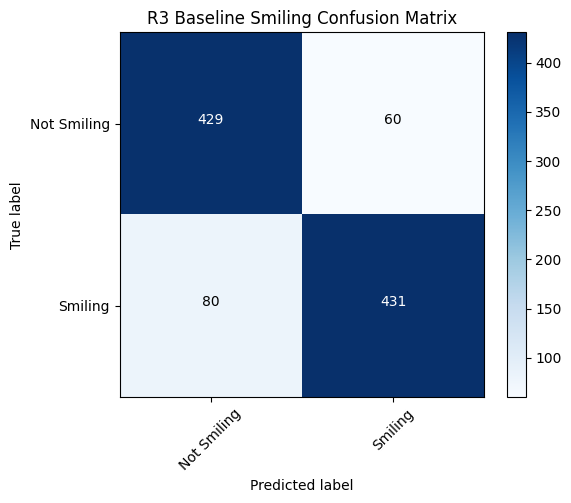

In [26]:
# Evaluate baseline smiling model
pred_probs_r3_base = model_r3_base.predict(test_gen_r3_base, verbose=0)
y_pred_r3_base = (pred_probs_r3_base.ravel() > 0.5).astype(int)
y_true_r3 = r3_test_df["Smiling"].values[:len(y_pred_r3_base)].astype(int)

cm_r3_base = confusion_matrix(y_true_r3, y_pred_r3_base)
acc_r3_base = accuracy_score(y_true_r3, y_pred_r3_base)

print("R3 Baseline Smiling Accuracy:", acc_r3_base)
print("\nR3 Baseline Smiling Confusion Matrix:")
print(cm_r3_base)
print("\nR3 Baseline Classification Report:")
print(classification_report(y_true_r3, y_pred_r3_base, target_names=["Not Smiling", "Smiling"]))

plot_conf_matrix(cm_r3_base, ["Not Smiling", "Smiling"], title="R3 Baseline Smiling Confusion Matrix")

In [27]:
# Multi input generator image and mouth 
class MultiInputDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, df, target_col="Smiling", meta_col="mouth_quartile",
                 batch_size=BATCH_SIZE, dim=IMG_SIZE, n_channels=3, shuffle=False):
        self.df = df.reset_index(drop=True).copy()
        self.target_col = target_col
        self.meta_col = meta_col
        self.batch_size = batch_size
        self.dim = dim
        self.n_channels = n_channels
        self.shuffle = shuffle
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        df_temp = self.df.iloc[indexes].reset_index(drop=True)
        X_img, X_meta, y = self.__data_generation(df_temp)
        return (X_img, X_meta), y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.df))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, df_temp):
        current_batch_size = len(df_temp)
        X_img = np.empty((current_batch_size, *self.dim, self.n_channels), dtype=np.float32)
        X_meta = np.zeros((current_batch_size, 4), dtype=np.float32)  # one-hot quartile
        y = np.empty((current_batch_size, 1), dtype=np.float32)

        for i, row in df_temp.iterrows():
            img_path = os.path.join(img_dir, row["image_id"])
            img = image.load_img(img_path, target_size=self.dim)
            img = image.img_to_array(img)
            img /= 255.0
            X_img[i] = img

            quartile = int(row[self.meta_col])
            X_meta[i, quartile] = 1.0

            y[i, 0] = float(row[self.target_col])

        return X_img, X_meta, y

In [28]:
# Build a model 
def build_model_with_metadata():
    image_input = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3), name="image_input")

    base_model = VGG16(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False

    x_img = base_model(image_input)
    x_img = tf.keras.layers.Flatten()(x_img)
    x_img = tf.keras.layers.Dense(256, activation="relu")(x_img)

    meta_input = tf.keras.Input(shape=(4,), name="meta_input")
    x_meta = tf.keras.layers.Dense(16, activation="relu")(meta_input)

    # Combine branches
    x = tf.keras.layers.Concatenate()([x_img, x_meta])
    x = tf.keras.layers.Dropout(0.3)(x)
    output = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=[image_input, meta_input], outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [29]:
# R3 generators
train_gen_r3_meta = MultiInputDataGenerator(r3_train_df, target_col="Smiling", meta_col="mouth_quartile",
                                            batch_size=BATCH_SIZE, shuffle=True)
val_gen_r3_meta   = MultiInputDataGenerator(r3_val_df, target_col="Smiling", meta_col="mouth_quartile",
                                            batch_size=BATCH_SIZE, shuffle=False)
test_gen_r3_meta  = MultiInputDataGenerator(r3_test_df, target_col="Smiling", meta_col="mouth_quartile",
                                            batch_size=BATCH_SIZE, shuffle=False)

In [30]:
# Train smiling model with mouth width quartile metadata
tf.keras.backend.clear_session()

model_r3_meta = build_model_with_metadata()

callbacks_r3_meta = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        min_delta=0.001,
        restore_best_weights=True,
        verbose=1
    )
]

history_r3_meta = model_r3_meta.fit(
    train_gen_r3_meta,
    validation_data=val_gen_r3_meta,
    epochs=EPOCHS,
    callbacks=callbacks_r3_meta,
    verbose=1
)

Epoch 1/5
  1/509 ━━━━━━━━━━━━━━━━━━━━ 37:15 4s/step - accuracy: 0.4688 - loss: 0.8379

W0000 00:00:1773942592.475033      73 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


462/509 ━━━━━━━━━━━━━━━━━━━━ 5s 127ms/step - accuracy: 0.7728 - loss: 0.5478

W0000 00:00:1773942651.156162      73 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - accuracy: 0.7778 - loss: 0.5346

W0000 00:00:1773942657.749643      75 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 74s 136ms/step - accuracy: 0.7779 - loss: 0.5343 - val_accuracy: 0.8940 - val_loss: 0.2822
Epoch 2/5


W0000 00:00:1773942661.754475      74 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8880 - loss: 0.2762 - val_accuracy: 0.9020 - val_loss: 0.2597
Epoch 3/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.8972 - loss: 0.2470 - val_accuracy: 0.8970 - val_loss: 0.2539
Epoch 4/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.9044 - loss: 0.2296 - val_accuracy: 0.8850 - val_loss: 0.2757
Epoch 5/5
509/509 ━━━━━━━━━━━━━━━━━━━━ 66s 129ms/step - accuracy: 0.9082 - loss: 0.2239 - val_accuracy: 0.8860 - val_loss: 0.2604
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


W0000 00:00:1773942928.493744      73 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update
W0000 00:00:1773942932.615075      76 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


R3 Metadata Smiling Accuracy: 0.876

R3 Metadata Smiling Confusion Matrix:
[[441  48]
 [ 76 435]]

R3 Metadata Classification Report:
              precision    recall  f1-score   support

 Not Smiling       0.85      0.90      0.88       489
     Smiling       0.90      0.85      0.88       511

    accuracy                           0.88      1000
   macro avg       0.88      0.88      0.88      1000
weighted avg       0.88      0.88      0.88      1000



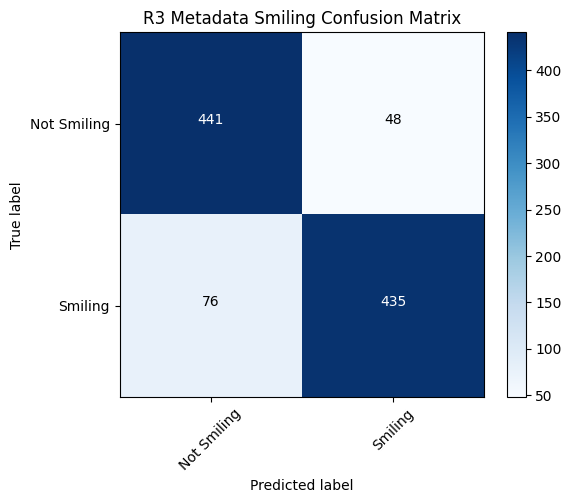

In [31]:
# Evaluate smiling model with mouth width metadata
pred_probs_r3_meta = model_r3_meta.predict(test_gen_r3_meta, verbose=0)
y_pred_r3_meta = (pred_probs_r3_meta.ravel() > 0.5).astype(int)
y_true_r3_meta = r3_test_df["Smiling"].values[:len(y_pred_r3_meta)].astype(int)

cm_r3_meta = confusion_matrix(y_true_r3_meta, y_pred_r3_meta)
acc_r3_meta = accuracy_score(y_true_r3_meta, y_pred_r3_meta)

print("R3 Metadata Smiling Accuracy:", acc_r3_meta)
print("\nR3 Metadata Smiling Confusion Matrix:")
print(cm_r3_meta)
print("\nR3 Metadata Classification Report:")
print(classification_report(y_true_r3_meta, y_pred_r3_meta, target_names=["Not Smiling", "Smiling"]))

plot_conf_matrix(cm_r3_meta, ["Not Smiling", "Smiling"], title="R3 Metadata Smiling Confusion Matrix")

In [32]:
# Final R3 comparison
gain_r3 = acc_r3_meta - acc_r3_base

print("R3 FINAL COMPARISON")
print(f"Baseline smiling accuracy:              {acc_r3_base:.4f}")
print(f"Smiling accuracy with mouth quartile:   {acc_r3_meta:.4f}")
print(f"Accuracy gain from metadata:            {gain_r3:.4f}")

R3 FINAL COMPARISON
Baseline smiling accuracy:              0.8600
Smiling accuracy with mouth quartile:   0.8760
Accuracy gain from metadata:            0.0160


In [33]:
# R3 conclusion
if acc_r3_meta > acc_r3_base:
    print("Conclusion: The mouth_width quartile appears to be a useful metadata feature for smiling classification.")
    print("Because accuracy improved when mouth_width metadata was included, it provides additional predictive information beyond the image alone.")
elif acc_r3_meta == acc_r3_base:
    print("Conclusion: The mouth_width quartile did not change performance in this experiment.")
    print("This suggests it may not add useful predictive information under the current setup.")
else:
    print("Conclusion: The mouth_width quartile did not improve smiling classification in this experiment.")
    print("Under the current setup, it does not appear to be a useful metadata feature.")

Conclusion: The mouth_width quartile appears to be a useful metadata feature for smiling classification.
Because accuracy improved when mouth_width metadata was included, it provides additional predictive information beyond the image alone.
